# ANALYSIS

In this notebook, we are analyzing the obtained results. Our objective was to see if we could establish a correlation between the percentage of parking lot occupancy at supermarkets/stores and a country's GDP per capita. To do this, we chose the United States as our target country because of the abundance of data available through Google Earth Engine. We selected Walmart as a proxy for retail stores because of their large number of locations and the fact that they predominantly feature outdoor parking lots.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_pib = pd.read_csv("../../Data/walmart_instore_deflator.csv")
df_occupancy = pd.read_csv("../../Data/naip_occupancy_results.csv")

In [3]:
df_pib.head()
df_pib.inflation

0     1.640277
1     3.156529
2     2.069450
3     1.464760
4     1.622188
5     0.118698
6     1.261513
7     2.130355
8     2.442477
9     1.811977
10    1.233684
11    4.698023
12    8.002731
13    4.116451
14    2.949439
Name: inflation, dtype: float64

In [4]:
df_occupancy.head()

,store_id,date,occupancy,year
0,42,2012-06-22,0.042379,2012
1,42,2015-08-20,0.048267,2015
2,42,2023-06-06,0.029109,2023
3,111,2012-06-25,0.027813,2012
4,111,2014-07-05,0.035563,2014


The Pearson correlation coefficient is: 0.8543


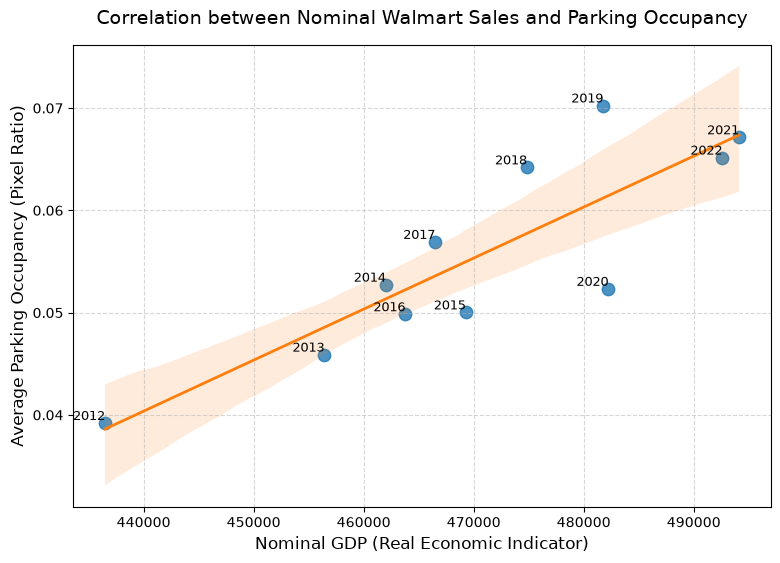

In [12]:
# Filter occupancy data to years up to 2022
df_occupancy_filtered = df_occupancy[(df_occupancy['year'] <= 2022) & (df_occupancy['year'] > 2011)]

# Group the occupancy data by year and calculate the mean occupancy for each year
df_occ_yearly = df_occupancy_filtered.groupby('year')['occupancy'].mean().reset_index()

# Merge the occupancy data with the normalized GDP data on the 'year' column
df_correlation = pd.merge(df_occ_yearly, df_pib[['year', 'Nominal_GDP']], on='year')

# Compute the Pearson correlation coefficient between Normalized_GDP and occupancy
correlation_matrix = df_correlation[['Nominal_GDP', 'occupancy']].corr()
correlation_value = correlation_matrix.loc['Nominal_GDP', 'occupancy']

print(f"The Pearson correlation coefficient is: {correlation_value:.4f}")

# Visualization
plt.figure(figsize=(9, 6))
sns.regplot(
    data=df_correlation, 
    x='Nominal_GDP', 
    y='occupancy', 
    scatter_kws={'s': 80, 'color': '#1f77b4', 'alpha': 0.8},
    line_kws={'color': '#ff7f0e', 'linewidth': 2}
)
for i in range(df_correlation.shape[0]):
    plt.text(
        df_correlation['Nominal_GDP'].iloc[i], 
        df_correlation['occupancy'].iloc[i], 
        str(int(df_correlation['year'].iloc[i])),
        verticalalignment='bottom', 
        horizontalalignment='right',
        fontsize=9
    )

plt.title('Correlation between Nominal Walmart Sales and Parking Occupancy', fontsize=14, pad=15)
plt.xlabel('Nominal GDP (Real Economic Indicator)', fontsize=12)
plt.ylabel('Average Parking Occupancy (Pixel Ratio)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()